In [2]:
# Importing Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
tips = sns.load_dataset("tips")
bill = tips["total_bill"].values
ip = tips["tip"].values

In [5]:
def local_weight(x0, X, tau):
    return np.exp(np.sum((X - x0) ** 2, axis=1) / (-2 * tau * tau))


def local_regression(X, y, tau):
    y_pred = np.zeros(len(X))

    for i in range(len(X)):
        weights = local_weight(X[i], X, tau)
        W = np.diag(weights)

        theta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ y)

        y_pred[i] = X[i] @ theta

    return y_pred

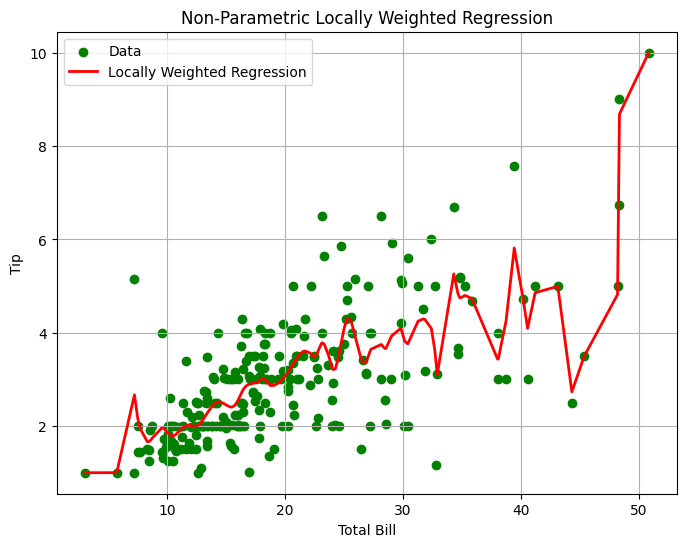

In [16]:
# Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Tips dataset
tips = sns.load_dataset("tips")

# Extract data
bill = tips["total_bill"].values
tip = tips["tip"].values

# Local Weight function
def local_weight(x0, X, tau):
    return np.exp(
        np.sum((X - x0) ** 2, axis=1) / (-2 * tau * tau)
    )

# Local Regression function
def local_regression(X, y, tau):
    y_pred = np.zeros(len(X))

    for i in range(len(X)):
        weights = local_weight(X[i], X, tau)
        W = np.diag(weights)

        theta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ y)

        y_pred[i] = X[i] @ theta

    return y_pred

# Prepare X and y
X = np.column_stack((np.ones(len(bill)), bill))
y = tip

# Set tau
tau = 0.5

# Predict
y_pred = local_regression(X, y, tau)

# Sort values for smooth plotting
sort_idx = np.argsort(bill)
xsort = bill[sort_idx]
ysort = y_pred[sort_idx]

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    bill,
    tip,
    color="green",
    label="Data"
)

plt.plot(
    xsort,
    ysort,
    color="red",
    linewidth=2,
    label="Locally Weighted Regression"
)

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Non-Parametric Locally Weighted Regression")

plt.legend()
plt.grid(True)
plt.show()